In [ ]:
# D:\project\gratuateDoc\storage 在这个地址获取原始图片

In [9]:
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False

In [8]:
# 验证安装 & 检查 GPU 环境
import torch
from ultralytics import YOLO
import ultralytics

print(f"ultralytics 版本: {ultralytics.__version__}")
print(f"PyTorch 版本:     {torch.__version__}")
print(f"CUDA 可用:        {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU 型号:         {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  未检测到 GPU，将使用 CPU 训练（速度较慢，建议用 Colab）")

ultralytics 版本: 8.3.249
PyTorch 版本:     2.5.1+cu121
CUDA 可用:        True
GPU 型号:         NVIDIA GeForce RTX 3060 Laptop GPU


In [1]:
from ultralytics import YOLO

model_v8n  = YOLO('yolov8n.pt')
model_v11n = YOLO('yolo11n.pt')
model_v11s = YOLO('yolo11s.pt')
model_v11m = YOLO('yolo11m.pt')

print(f"YOLOv8n  参数量: {sum(p.numel() for p in model_v8n.model.parameters()):,}")
print(f"YOLOv11n 参数量: {sum(p.numel() for p in model_v11n.model.parameters()):,}")
print(f"YOLOv11s 参数量: {sum(p.numel() for p in model_v11s.model.parameters()):,}")
print(f"YOLOv11m 参数量: {sum(p.numel() for p in model_v11m.model.parameters()):,}")
print("✅ 所有模型载入成功")

YOLOv8n  参数量: 3,157,200
YOLOv11n 参数量: 2,624,080
YOLOv11s 参数量: 9,458,752
YOLOv11m 参数量: 20,114,688
✅ 所有模型载入成功


In [ ]:
##  一些启动和备注

In [20]:
IMAGES_DIR = 'datasets/jiandu_slips/images/train'
LABELS_DIR = 'datasets/jiandu_slips/labels/train'

import os, cv2, random
import matplotlib.pyplot as plt

def validate_yolo_labels(images_dir, labels_dir, num_samples=9):
    image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png'))]
    if not image_files:
        print("⚠️  images 目录为空")
        return
    samples = random.sample(image_files, min(num_samples, len(image_files)))
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    for ax, img_file in zip(axes.flatten(), samples):
        img_path   = os.path.join(images_dir, img_file)
        label_path = os.path.join(labels_dir, os.path.splitext(img_file)[0] + '.txt')
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        _, cx, cy, bw, bh = map(float, parts)
                        x1 = int((cx - bw/2) * w)
                        y1 = int((cy - bh/2) * h)
                        x2 = int((cx + bw/2) * w)
                        y2 = int((cy + bh/2) * h)
                        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        ax.imshow(img)
        ax.set_title(img_file[:25])
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('dataset_validation.png', dpi=150)
    plt.show()
    print("✅ 验证图已保存: dataset_validation.png")

validate_yolo_labels(IMAGES_DIR, LABELS_DIR)

<Figure size 1500x1500 with 9 Axes>

✅ 验证图已保存: dataset_validation.png


In [ ]:
from ultralytics import YOLO
import torch

print(f"使用设备: {'GPU: ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

model_v8 = YOLO('yolov8n.pt')
results_v8 = model_v8.train(
    data='./datasets/jiandu_slips.yaml',
    epochs=50,           # 先跑 50 轮观察收敛趋势
    imgsz=640,
    batch=8,             # 显存不够改为 4
    freeze=10,           # 冻结前 10 层 backbone，防止小数据集过拟合
    lr0=0.001,           # 微调用小学习率（比默认 0.01 小 10 倍）
    lrf=0.01,
    # 简牍专用数据增强
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=10,          # 简牍可能倾斜
    scale=0.5,
    fliplr=0.0,          # 简牍有方向性，不翻转
    flipud=0.0,
    mosaic=0.5,
    project='./runs/slip_detection',
    name='v8n_baseline',
    save_period=10,
    plots=True,
)

使用设备: GPU: NVIDIA GeForce RTX 3060 Laptop GPU
New https://pypi.org/project/ultralytics/8.4.31 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.249  Python-3.9.21 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/jiandu_slips.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.5

train: Scanning D:\A学习资料\逆流河\少年游\道尊\jtext\d2l-zh\pytorch\2026\storage\dataset2\datasets\jiandu_slips\labels\train.cache... 32 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 32/32  0.0s
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.20.0 ms, read: 599.5174.3 MB/s, size: 1826.8 KB)
val: Scanning D:\A学习资料\逆流河\少年游\道尊\jtext\d2l-zh\pytorch\2026\storage\dataset2\datasets\jiandu_slips\labels\val.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 4.0Kit/s 0.0s
Plotting labels to D:\A\\\\jtext\d2l-zh\pytorch\2026\storage\dataset2\runs\slip_detection\v8n_baseline2\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.001' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with paramete


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      37/50     0.826G      1.041     0.7757     0.9532        153        640: 100% ━━━━━━━━━━━━ 4/4 6.9it/s 0.6s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 11.1it/s 0.1s
                   all          4         49      0.977       0.98      0.968       0.58

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      38/50     0.826G      0.954     0.7447     0.9706         92        640: 100% ━━━━━━━━━━━━ 4/4 7.0it/s 0.6s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 9.9it/s 0.1ss
                   all          4         49      0.977       0.98      0.968       0.58

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      39/50     0.826G      1.022     0.7598     0.9819         99        640: 100% ━━━━━━━━━━━━ 

In [5]:
from ultralytics import YOLO

model_v11 = YOLO('yolo11s.pt')
results_v11 = model_v11.train(
    data='./datasets/jiandu_slips.yaml',
    epochs=50,
    imgsz=640,
    batch=8,
    freeze=10,
    lr0=0.001,
    lrf=0.01,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=10,
    scale=0.5,
    fliplr=0.0,
    flipud=0.0,
    mosaic=0.5,
    project='./runs/slip_detection',
    name='v11s_main',
    save_period=10,
    plots=True,
    
    workers=0, 
)

New https://pypi.org/project/ultralytics/8.4.31 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.30  Python-3.9.21 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/jiandu_slips.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, nam

Freezing layer 'model.8.m.0.m.0.cv1.conv.weight'
Freezing layer 'model.8.m.0.m.0.cv1.bn.weight'
Freezing layer 'model.8.m.0.m.0.cv1.bn.bias'
Freezing layer 'model.8.m.0.m.0.cv2.conv.weight'
Freezing layer 'model.8.m.0.m.0.cv2.bn.weight'
Freezing layer 'model.8.m.0.m.0.cv2.bn.bias'
Freezing layer 'model.8.m.0.m.1.cv1.conv.weight'
Freezing layer 'model.8.m.0.m.1.cv1.bn.weight'
Freezing layer 'model.8.m.0.m.1.cv1.bn.bias'
Freezing layer 'model.8.m.0.m.1.cv2.conv.weight'
Freezing layer 'model.8.m.0.m.1.cv2.bn.weight'
Freezing layer 'model.8.m.0.m.1.cv2.bn.bias'
Freezing layer 'model.9.cv1.conv.weight'
Freezing layer 'model.9.cv1.bn.weight'
Freezing layer 'model.9.cv1.bn.bias'
Freezing layer 'model.9.cv2.conv.weight'
Freezing layer 'model.9.cv2.bn.weight'
Freezing layer 'model.9.cv2.bn.bias'
Freezing layer 'model.23.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed 
train: Fast image access  (ping: 0.20.1 ms, read: 884.888.2 MB/s, size: 1749.1 KB)
tr

      15/50      1.25G      1.043     0.7187      1.005        191        640: 100% ━━━━━━━━━━━━ 4/4 4.5it/s 0.9s0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.5it/s 0.7s
                   all          4         49       0.94      0.955      0.963      0.584

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      16/50      1.25G      1.029     0.6721     0.9918        111        640: 100% ━━━━━━━━━━━━ 4/4 4.6it/s 0.9s0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.5it/s 0.7s
                   all          4         49       0.94      0.955      0.963      0.584

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      17/50      1.25G      1.081     0.6915      1.029        132        640: 100% ━━━━━━━━━━━━ 4/4 4.1it/s 1.0s0.3s
                 Class     Images  Instances      Box(P     


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      35/50      1.25G      1.069     0.6157      1.023        145        640: 100% ━━━━━━━━━━━━ 4/4 4.3it/s 0.9s0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.4it/s 0.7s
                   all          4         49      0.929       0.98      0.975      0.574

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      36/50      1.25G      1.001     0.5725     0.9562        117        640: 100% ━━━━━━━━━━━━ 4/4 4.1it/s 1.0s0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.4it/s 0.7s
                   all          4         49      0.929       0.98      0.975      0.574

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      37/50      1.25G      1.057     0.6223     0.9939         98        640: 100% ━━━━━━━━━━━━ 4/

In [1]:
from ultralytics import YOLO

def evaluate(model_path: str, label: str):
    model = YOLO(model_path)
    metrics = model.val(data='datasets/jiandu_slips.yaml', split='test')
    print(f"\n=== {label} ===")
    print(f"  mAP50:    {metrics.box.map50:.4f}   ← 主要指标")
    print(f"  mAP50-95: {metrics.box.map:.4f}")
    print(f"  精确率:   {metrics.box.mp:.4f}")
    print(f"  召回率:   {metrics.box.mr:.4f}")
    return metrics

m1 = evaluate('yolov8n.pt',  '预训练 YOLOv8n（无微调）')
m2 = evaluate('yolo11s.pt',  '预训练 YOLOv11s（无微调）')
m3 = evaluate('./runs/slip_detection/v8n_baseline/weights/best.pt', '微调 YOLOv8n')
m4 = evaluate('./runs/slip_detection/v11s_main/weights/best.pt',    '微调 YOLOv11s')

print("\n" + "="*40)
print(f"  预训练 YOLOv8n  → {m1.box.map50:.4f}")
print(f"  微调   YOLOv8n  → {m3.box.map50:.4f}")
print(f"  预训练 YOLOv11s → {m2.box.map50:.4f}")
print(f"  微调   YOLOv11s → {m4.box.map50:.4f}")

Ultralytics 8.4.30  Python-3.9.21 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access  (ping: 0.30.2 ms, read: 121.7104.9 MB/s, size: 1592.1 KB)
val: Scanning D:\A学习资料\逆流河\少年游\道尊\jtext\d2l-zh\pytorch\2026\storage\dataset2\datasets\jiandu_slips\labels\test.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.7s/it 1.7s
                   all          4         72      0.292     0.0972      0.174      0.111
                person          4         72      0.292     0.0972      0.174      0.111
Speed: 1.1ms preprocess, 47.2ms inference, 0.0ms loss, 3.8ms postprocess per image
Results saved to C:\Users\LENOVO\runs\detect\val12

=== 预训练 YOLOv8n（无微调） ===
  mAP50:    0.1741   ← 主要指标
  mAP50-95: 0.1110
  精确率:   0.2917
  召回率:   0.0972
Ultra

In [6]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from PIL import Image
import io
import os
import ipywidgets as widgets
from IPython.display import display, clear_output

# 强制 Matplotlib 在 Notebook 中内联显示
%matplotlib inline

# --- 1. 配置区 ---
MY_MODEL_PATH = r'D:\A学习资料\逆流河\少年游\道尊\jtext\d2l-zh\pytorch\2026\storage\dataset2\runs\slip_detection\v11s_main\weights\best.pt' 
TEMP_FILENAME = "current_predict_cache.jpg"
# ----------------

# 加载模型
try:
    model = YOLO(MY_MODEL_PATH)
    print("✅ 模型加载成功！")
except Exception as e:
    print(f"❌ 加载失败：{e}")

# 定义识别逻辑
def run_inference(image_bytes):
    # 1. 将二进制流转为 PIL 图片
    img = Image.open(io.BytesIO(image_bytes))
    
    # 2. 保存临时缓存文件
    img.save(TEMP_FILENAME)
    
    try:
        # 3. 执行推理 (设置 verbose=False 减少后台日志输出)
        results = model.predict(source=TEMP_FILENAME, conf=0.25, verbose=False)
        
        # 4. 绘图展示
        for r in results:
            # 这里的 plot 会绘制出带标签和框的 BGR 图像
            im_array = r.plot()  
            im_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)
            
            plt.figure(figsize=(12, 12))
            plt.imshow(im_rgb)
            plt.axis('off')
            plt.title(f"Found: {len(r.boxes)} objects")
            plt.show() # 显式触发显示
            
    finally:
        # 5. 识别结束后立即删除缓存图
        if os.path.exists(TEMP_FILENAME):
            os.remove(TEMP_FILENAME)
            # print("🧹 临时缓存已清理")

# 创建交互组件
uploader = widgets.FileUpload(accept='.jpg,.png,.jpeg', multiple=False)
output = widgets.Output()

def on_upload_change(change):
    with output:
        # 每次上传新图前，先清空之前的识别结果展示
        clear_output(wait=True) 
        
        if not uploader.value:
            return
        
        try:
            # 适配不同版本的 ipywidgets
            if isinstance(uploader.value, tuple):
                file_info = uploader.value[0]
            else:
                file_info = list(uploader.value.values())[0]
            
            content = file_info['content']
            # print(f"正在分析图片: {file_info['name']}...")
            
            # 执行识别与绘图
            run_inference(content)
            
        except Exception as e:
            print(f"处理过程中出错: {e}")

# 绑定事件
uploader.observe(on_upload_change, names='value')

print("👇 请点击下方按钮上传简牍图片进行识别：")
display(uploader, output)

✅ 模型加载成功！
👇 请点击下方按钮上传简牍图片进行识别：


FileUpload(value=(), accept='.jpg,.png,.jpeg', description='Upload')

Output()

In [ ]:
### 目前我的模型训练效果展示上还不错，但是有点小问题，会有的框是两个框或者三个框重叠在一起，有什么方案调整

In [ ]:
NMS 参数调整问题



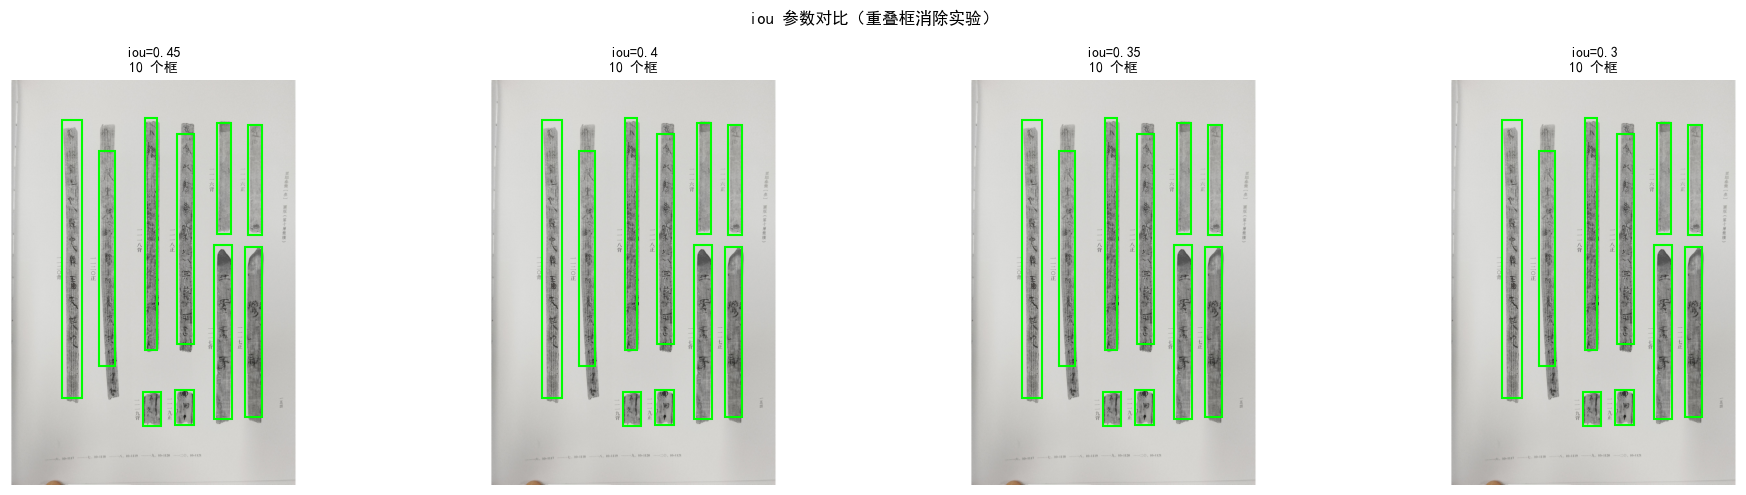

In [12]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2

model = YOLO('runs/slip_detection/v11s_main/weights/best.pt')

# 改成你有重叠框问题的那张图
TEST_IMG = 'D:/project/gratuateDoc/storage/images/page_79.jpg'

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('iou 参数对比（重叠框消除实验）')

for ax, iou_val in zip(axes, [0.45, 0.40, 0.35, 0.30]):
    img = cv2.cvtColor(cv2.imread(TEST_IMG), cv2.COLOR_BGR2RGB)
    results = model.predict(TEST_IMG, conf=0.30, iou=iou_val, verbose=False)
    boxes = results[0].boxes

    ax.imshow(img)
    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=1.5, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
    ax.set_title(f'iou={iou_val}\n{len(boxes)} 个框', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('nms_iou_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

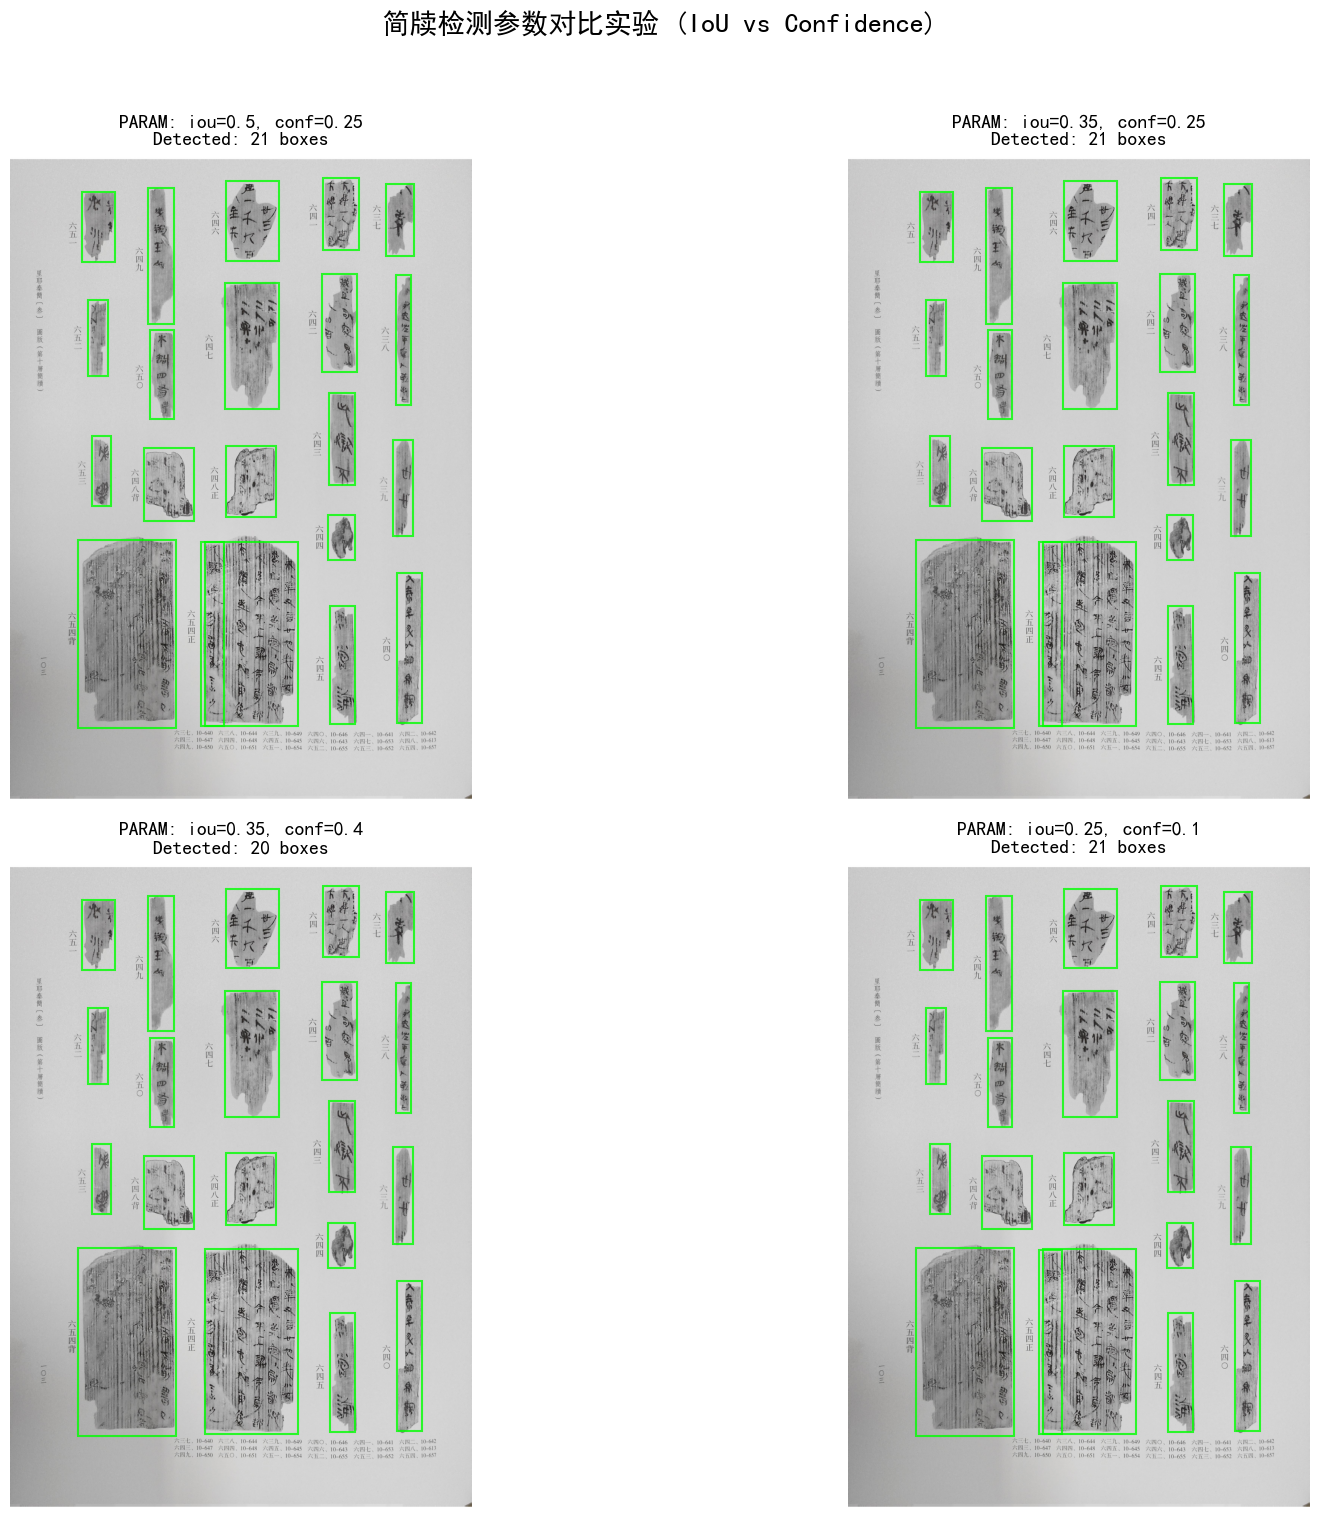

In [14]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO
import os

# --- 配置区 ---
MODEL_PATH = r'D:\A学习资料\逆流河\少年游\道尊\jtext\d2l-zh\pytorch\2026\storage\dataset2\runs\slip_detection\v11s_main\weights\best.pt'
TEST_IMG = r'D:\project\gratuateDoc\storage\images\page_128.jpg'

# 加载模型
model = YOLO(MODEL_PATH)

# 设置对比参数组合 (IoU 阈值, Conf 置信度)
# IoU 越小，去重越狠；Conf 越大，过滤越严
param_combinations = [
    (0.50, 0.25), (0.35, 0.25),  # 固定 Conf，对比 IoU (去重效果)
    (0.35, 0.40), (0.25, 0.10)   # 尝试极端组合
]

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()
fig.suptitle('简牍检测参数对比实验 (IoU vs Confidence)', fontsize=20)

for ax, (iou_val, conf_val) in zip(axes, param_combinations):
    # 读取图片
    img = cv2.imread(TEST_IMG)
    if img is None:
        print(f"错误：找不到图片 {TEST_IMG}")
        break
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 推理，开启 agnostic_nms (如果是单类检测建议开启)
    # 并模拟后端设置的参数
    results = model.predict(
        source=TEST_IMG, 
        conf=conf_val, 
        iou=iou_val, 
        agnostic_nms=True, # 强制跨类去重
        verbose=False
    )
    
    boxes = results[0].boxes
    ax.imshow(img)
    
    # 绘制检测框
    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=1.5, edgecolor='lime', facecolor='none', alpha=0.8
        )
        ax.add_patch(rect)
    
    # 标题显示参数信息
    ax.set_title(f'PARAM: iou={iou_val}, conf={conf_val}\nDetected: {len(boxes)} boxes', 
                 fontsize=14, fontweight='bold')
    ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('parameter_optimization_results.png', dpi=150)
plt.show()